# E-Commerce Fraud Detection

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Core ML
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, matthews_corrcoef,
                             confusion_matrix, classification_report)

# Boosting Models
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import IsolationForest

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import optuna

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Explainability
import shap

# Graph Features (NetworkX)
import networkx as nx
from collections import defaultdict

# Drift Monitoring
from scipy.stats import ks_2samp

# Utilities
import joblib
import pickle
from datetime import datetime


#### LOADINg AND EXPLORING DATA


In [3]:
# Data Loading
RAW_DATA = "online_retail_ii.xlsx"
df_raw = pd.read_excel(RAW_DATA)

print(f"Dataset Shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist()}")
print(f"\nData Types:\n{df_raw.dtypes}")
print(f"\nMissing Values:\n{df_raw.isnull().sum()}")

df_raw.head()

Dataset Shape: (525461, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# statistics
df_raw.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


#### DATA CLEANING

In [5]:
# Clean column names
df = df_raw.copy()
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
print(f"Cleaned column names: {df.columns.tolist()}")

Cleaned column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']


In [6]:
# Handle Customer ID
if 'Customer_ID' not in df.columns:
    possible_names = ['CustomerID', 'CustomerId', 'Customer_id']
    for name in possible_names:
        if name in df.columns:
            df = df.rename(columns={name: 'Customer_ID'})
            break

print(f"Customer ID column exists: {'Customer_ID' in df.columns}")

Customer ID column exists: True


In [7]:
# Droping rows with missing Customer ID
initial_rows = len(df)
df = df.dropna(subset=['Customer_ID'])
print(f"Removed rows with missing Customer ID: {initial_rows - len(df)}")


# Keep negative quantities (fraud often involves returns)
df['Is_Return'] = (df['Quantity'] < 0).astype(int)
df['Quantity_Abs'] = df['Quantity'].abs()


# Removing duplicates
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed duplicate rows: {initial_rows - len(df)}")


# Converting InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extracting time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.weekday
df['IsWeekend'] = (df['Weekday'] >= 5).astype(int)


# Total Amount (using absolute quantity)
df['TotalAmount'] = df['Quantity_Abs'] * df['Price']

# Log transform for skewed features
df['Log_TotalAmount'] = np.log1p(df['TotalAmount'])
df['Log_Quantity'] = np.log1p(df['Quantity_Abs'])
df['Log_Price'] = np.log1p(df['Price'])

print(f"Cleaned data shape: {df.shape}")
df.head()

Removed rows with missing Customer ID: 107927
Removed duplicate rows: 6771
Cleaned data shape: (410763, 20)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Is_Return,Quantity_Abs,Year,Month,Day,Hour,Weekday,IsWeekend,TotalAmount,Log_TotalAmount,Log_Quantity,Log_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,83.4,4.435567,2.564949,2.073172
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,81.0,4.406719,2.564949,2.047693
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,0,12,2009,12,1,7,1,0,81.0,4.406719,2.564949,2.047693
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,0,48,2009,12,1,7,1,0,100.8,4.623010,3.891820,1.131402
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,0,24,2009,12,1,7,1,0,30.0,3.433987,3.218876,0.810930


#### FEATURE ENGINEERING - RFM & BEHAVIORAL


In [8]:
# Sorting by customer and date
df = df.sort_values(['Customer_ID', 'InvoiceDate'])


# Creating invoice-level aggregates
invoice_stats = df.groupby('Invoice').agg({
    'Quantity_Abs': 'sum',
    'TotalAmount': 'sum',
    'Customer_ID': 'first',
    'InvoiceDate': 'first',
    'Country': 'first'
}).rename(columns={
    'Quantity_Abs': 'Invoice_Quantity',
    'TotalAmount': 'Invoice_Amount'
}).reset_index()

invoice_stats.head()


# Sorting invoices by date
invoice_stats = invoice_stats.sort_values(['Customer_ID', 'InvoiceDate'])

In [9]:
# RFM Features
rfm_features = []

for customer_id in invoice_stats['Customer_ID'].unique():
    customer_invoices = invoice_stats[invoice_stats['Customer_ID'] == customer_id].copy()

    if len(customer_invoices) == 0:
        continue

    # Monetary: total spend
    total_spend = customer_invoices['Invoice_Amount'].sum()

    # Frequency: number of purchases
    purchase_count = len(customer_invoices)

    # Recency: days since last purchase
    last_purchase = customer_invoices['InvoiceDate'].max()
    first_purchase = customer_invoices['InvoiceDate'].min()

    # Customer lifetime
    customer_lifetime = (last_purchase - first_purchase).days

    # Average purchase value
    avg_purchase = customer_invoices['Invoice_Amount'].mean()
    std_purchase = customer_invoices['Invoice_Amount'].std()

    # Purchase regularity (std of days between purchases)
    if len(customer_invoices) > 1:
        days_between = customer_invoices['InvoiceDate'].diff().dt.days.dropna()
        purchase_regularity = days_between.std()
        avg_days_between = days_between.mean()
    else:
        purchase_regularity = 0
        avg_days_between = 0

    rfm_features.append({
        'Customer_ID': customer_id,
        'RFM_Monetary': total_spend,
        'RFM_Frequency': purchase_count,
        'RFM_Recency': (invoice_stats['InvoiceDate'].max() - last_purchase).days,
        'RFM_AvgPurchase': avg_purchase,
        'RFM_StdPurchase': std_purchase if not pd.isna(std_purchase) else 0,
        'RFM_CustomerLifetime': customer_lifetime,
        'RFM_AvgDaysBetween': avg_days_between,
        'RFM_PurchaseRegularity': purchase_regularity
    })

rfm_df = pd.DataFrame(rfm_features)
print(f"RFM features created for {len(rfm_df)} customers")
rfm_df.head()


# Merging RFM features back to main dataframe
df = df.merge(rfm_df, on='Customer_ID', how='left')

RFM features created for 4383 customers


In [10]:
# Fill NaN values
rfm_cols = ['RFM_Monetary', 'RFM_Frequency', 'RFM_Recency', 'RFM_AvgPurchase',
            'RFM_StdPurchase', 'RFM_CustomerLifetime', 'RFM_AvgDaysBetween',
            'RFM_PurchaseRegularity']
df[rfm_cols] = df[rfm_cols].fillna(0)

In [11]:
# Behavioral drift features
df['Amount_vs_CustomerAvg'] = df['TotalAmount'] / (df['RFM_AvgPurchase'] + 1)
df['Amount_Diff_CustomerAvg'] = df['TotalAmount'] - df['RFM_AvgPurchase']
df['Quantity_vs_CustomerAvg'] = df['Quantity_Abs'] / (df['RFM_Monetary'] / (df['RFM_Frequency'] + 1) + 1)

# Z-scores
df['Amount_ZScore'] = (df['TotalAmount'] - df['RFM_AvgPurchase']) / (df['RFM_StdPurchase'] + 1)

In [12]:
# Velocity features (transactions in last 7/30 days)
def add_velocity_features(df):
    df = df.copy()
    df = df.sort_values(['Customer_ID', 'InvoiceDate'])

    # Initialize columns
    df['Txns_Last7Days'] = 0
    df['Txns_Last30Days'] = 0
    df['Amount_Last7Days'] = 0
    df['Amount_Last30Days'] = 0

    for cust_id in df['Customer_ID'].unique():
        mask = df['Customer_ID'] == cust_id
        cust_indices = df[mask].index

        for i, idx in enumerate(cust_indices):
            current_date = df.loc[idx, 'InvoiceDate']

            # Look back at previous transactions
            prev_indices = cust_indices[:i]
            if len(prev_indices) > 0:
                prev_dates = df.loc[prev_indices, 'InvoiceDate']
                prev_amounts = df.loc[prev_indices, 'TotalAmount']

                # Last 7 days
                mask_7days = (current_date - prev_dates) <= timedelta(days=7)
                df.loc[idx, 'Txns_Last7Days'] = mask_7days.sum()
                df.loc[idx, 'Amount_Last7Days'] = prev_amounts[mask_7days].sum()

                # Last 30 days
                mask_30days = (current_date - prev_dates) <= timedelta(days=30)
                df.loc[idx, 'Txns_Last30Days'] = mask_30days.sum()
                df.loc[idx, 'Amount_Last30Days'] = prev_amounts[mask_30days].sum()

    # Velocity ratios
    df['Velocity_7to30_Ratio'] = df['Txns_Last7Days'] / (df['Txns_Last30Days'] + 1)
    df['Velocity_Spike'] = (df['Txns_Last7Days'] > 3 * (df['Txns_Last30Days'] / 4 + 1)).astype(int)

    return df

df = add_velocity_features(df)

In [13]:
# Country encoding and risk scoring
country_stats = df.groupby('Country').agg({
    'Invoice': 'nunique',
    'Customer_ID': 'nunique'
}).reset_index()

country_stats['Country_Popularity'] = country_stats['Invoice'] / country_stats['Invoice'].sum()

# Merging back
df = df.merge(country_stats[['Country', 'Country_Popularity']], on='Country', how='left')

# Country risk score (manual mapping for demo)
high_risk_countries = ['Brazil', 'Russia', 'Nigeria', 'India', 'China']
medium_risk_countries = ['USA', 'Australia', 'Canada']

df['Country_Risk'] = 1  # Low risk default
df.loc[df['Country'].isin(medium_risk_countries), 'Country_Risk'] = 2
df.loc[df['Country'].isin(high_risk_countries), 'Country_Risk'] = 3


# Time-based features
df['Night_Transaction'] = ((df['Hour'] >= 22) | (df['Hour'] <= 5)).astype(int)
df['EarlyMorning_Transaction'] = ((df['Hour'] >= 3) & (df['Hour'] <= 6)).astype(int)

#### GRAPH FEATURES (Network Analysis)


In [14]:
## Creating transaction network
G = nx.Graph()

# Adding edges between customers who share Country (simplified network)
country_customers = df.groupby('Country')['Customer_ID'].unique().to_dict()

for country, customers in country_customers.items():
    customers_list = list(customers)
    for i in range(len(customers_list)):
        for j in range(i+1, len(customers_list)):
            if i < 10 and j < 10:  # Limit for demo
                G.add_edge(customers_list[i], customers_list[j])

print(f"Network created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


# Calculating network centrality
centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=10)

# Creating centrality features
df['Network_Degree'] = df['Customer_ID'].map(centrality).fillna(0)
df['Network_Betweenness'] = df['Customer_ID'].map(betweenness).fillna(0)

Network created with 195 nodes and 746 edges


#### CREATING SYNTHETIC FRAUD LABELS


In [15]:
df['Fraud_Label'] = 0

# Rule 1: High velocity + unusual amount
condition1 = (df['Txns_Last7Days'] >= 3) & (df['Amount_ZScore'].abs() > 2.5)
df.loc[condition1, 'Fraud_Label'] = 1
print(f"Rule 1 (High velocity + unusual amount): {condition1.sum()} transactions")

# Rule 2: Night transactions + high amount + new customer
recent_customers = df.groupby('Customer_ID')['InvoiceDate'].min().reset_index()
recent_customers.columns = ['Customer_ID', 'First_Purchase']
df = df.merge(recent_customers, on='Customer_ID', how='left')
df['Is_NewCustomer'] = (df['InvoiceDate'] - df['First_Purchase']).dt.days < 7

condition2 = (df['Night_Transaction'] == 1) & (df['Amount_ZScore'].abs() > 2) & (df['Is_NewCustomer'] == 1)
df.loc[condition2, 'Fraud_Label'] = 1
print(f"Rule 2 (Night + high amount + new): {condition2.sum()} transactions")

# Rule 3: Return manipulation (high return rate)
customer_returns = df.groupby('Customer_ID')['Is_Return'].mean().reset_index()
customer_returns.columns = ['Customer_ID', 'Return_Rate']
df = df.merge(customer_returns, on='Customer_ID', how='left')

condition3 = (df['Is_Return'] == 1) & (df['Return_Rate'] > 0.5) & (df['TotalAmount'] > df['TotalAmount'].median())
df.loc[condition3, 'Fraud_Label'] = 1
print(f"Rule 3 (Return manipulation): {condition3.sum()} transactions")

# Rule 4: Extreme amount + low frequency
condition4 = (df['Amount_ZScore'].abs() > 3) & (df['RFM_Frequency'] <= 2)
df.loc[condition4, 'Fraud_Label'] = 1
print(f"Rule 4 (Extreme amount + low frequency): {condition4.sum()} transactions")

# Rule 5: High risk country + unusual hour
condition5 = (df['Country_Risk'] >= 2) & (df['EarlyMorning_Transaction'] == 1) & (df['Amount_ZScore'].abs() > 1.5)
df.loc[condition5, 'Fraud_Label'] = 1
print(f"Rule 5 (High risk country + unusual hour): {condition5.sum()} transactions")

# Ensuring per-invoice consistency (if one item in invoice is fraud, whole invoice is fraud)
df['Fraud_Label'] = df.groupby('Invoice')['Fraud_Label'].transform('max')

print(f"\nFraud Distribution:")
print(df['Fraud_Label'].value_counts())
print(f"Fraud Rate: {df['Fraud_Label'].mean():.4f} ({df['Fraud_Label'].mean()*100:.2f}%)")


# Droping temporary columns
df = df.drop(['First_Purchase', 'Return_Rate'], axis=1)

Rule 1 (High velocity + unusual amount): 61455 transactions
Rule 2 (Night + high amount + new): 0 transactions
Rule 3 (Return manipulation): 231 transactions
Rule 4 (Extreme amount + low frequency): 38310 transactions
Rule 5 (High risk country + unusual hour): 0 transactions

Fraud Distribution:
Fraud_Label
0    338554
1     72209
Name: count, dtype: int64
Fraud Rate: 0.1758 (17.58%)


#### UNSUPERVISED ANOMALY DETECTION (Isolation Forest)


In [16]:
# Selecting features for isolation forest
iso_features = ['Log_TotalAmount', 'Log_Quantity', 'Amount_ZScore',
                'Txns_Last7Days', 'Txns_Last30Days', 'Night_Transaction']

iso_df = df[iso_features].fillna(0).sample(min(50000, len(df)), random_state=42)

# Training Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
iso_forest.fit(iso_df)

# Predict anomaly scores for all data
df_iso_features = df[iso_features].fillna(0)
df['Anomaly_Score'] = iso_forest.decision_function(df_iso_features)
df['Anomaly_Prediction'] = iso_forest.predict(df_iso_features)
df['Is_Anomaly'] = (df['Anomaly_Prediction'] == -1).astype(int)

print(f"Anomaly detection complete. Found {df['Is_Anomaly'].sum()} anomalies")

Anomaly detection complete. Found 21136 anomalies


#### FINAL FEATURE SELECTION


In [17]:
# Defining final feature set

feature_columns = [
    # Transaction features
    'Log_TotalAmount', 'Log_Quantity', 'Log_Price',
    'Is_Return', 'Night_Transaction', 'EarlyMorning_Transaction',
    'Weekday', 'IsWeekend', 'Hour',

    # RFM features
    'RFM_Monetary', 'RFM_Frequency', 'RFM_Recency',
    'RFM_AvgPurchase', 'RFM_StdPurchase',
    'RFM_AvgDaysBetween', 'RFM_PurchaseRegularity',

    # Behavioral drift
    'Amount_vs_CustomerAvg', 'Amount_Diff_CustomerAvg',
    'Quantity_vs_CustomerAvg', 'Amount_ZScore',

    # Velocity
    'Txns_Last7Days', 'Txns_Last30Days',
    'Amount_Last7Days', 'Amount_Last30Days',
    'Velocity_7to30_Ratio', 'Velocity_Spike',

    # Country
    'Country_Popularity', 'Country_Risk',

    # Network
    'Network_Degree', 'Network_Betweenness',

    # Anomaly detection
    'Anomaly_Score', 'Is_Anomaly'
]

# Verifying all features exist
available_features = [col for col in feature_columns if col in df.columns]
missing_features = set(feature_columns) - set(available_features)

print(f"Features available: {len(available_features)}")
print(f"Missing features: {missing_features}")

Features available: 32
Missing features: set()


#### Preparing modeling dataset

In [18]:
modeling_df = df[available_features + ['Fraud_Label', 'InvoiceDate', 'Customer_ID']].copy()

# Handlling any infinite values
modeling_df = modeling_df.replace([np.inf, -np.inf], np.nan)
modeling_df = modeling_df.fillna(0)

print(f"\nModeling Data Shape: {modeling_df.shape}")
print(f"Features: {len(available_features)}")
print(f"Target distribution:\n{modeling_df['Fraud_Label'].value_counts()}")


Modeling Data Shape: (410763, 35)
Features: 32
Target distribution:
Fraud_Label
0    338554
1     72209
Name: count, dtype: int64


#### TRAIN/TEST SPLIT - TIME-BASED


In [19]:
# Sorting by date
modeling_df = modeling_df.sort_values('InvoiceDate')

# Split by time (80% oldest, 20% newest)
split_date = modeling_df['InvoiceDate'].quantile(0.8)

train_df = modeling_df[modeling_df['InvoiceDate'] <= split_date]
test_df = modeling_df[modeling_df['InvoiceDate'] > split_date]


print("TIME-BASED SPLIT")
print("="*60)
print(f"Split date: {split_date}")
print(f"Train period: {train_df['InvoiceDate'].min()} to {train_df['InvoiceDate'].max()}")
print(f"Test period: {test_df['InvoiceDate'].min()} to {test_df['InvoiceDate'].max()}")
print(f"Train size: {len(train_df)} ({len(train_df)/len(modeling_df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(modeling_df)*100:.1f}%)")
print(f"Train fraud rate: {train_df['Fraud_Label'].mean():.4f}")
print(f"Test fraud rate: {test_df['Fraud_Label'].mean():.4f}")

TIME-BASED SPLIT
Split date: 2010-10-26 14:00:00
Train period: 2009-12-01 07:45:00 to 2010-10-26 14:00:00
Test period: 2010-10-26 14:12:00 to 2010-12-09 20:01:00
Train size: 328620 (80.0%)
Test size: 82143 (20.0%)
Train fraud rate: 0.1650
Test fraud rate: 0.2191


##### Prepare features and target

In [20]:
feature_cols = [col for col in available_features if col in train_df.columns]

X_train = train_df[feature_cols]
y_train = train_df['Fraud_Label']
X_test = test_df[feature_cols]
y_test = test_df['Fraud_Label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (328620, 32)
X_test shape: (82143, 32)


#### SCALING WITH ROBUSTSCALER


In [21]:
# Using RobustScaler (handles outliers better)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)


print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")

Train scaled shape: (328620, 32)
Test scaled shape: (82143, 32)


#### HANDLLING CLASS IMBALANCE WITH SMOTE


In [22]:
# Applying SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.3)  # 30% fraud after SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("CLASS IMBALANCE HANDLING")
print("="*60)
print(f"Original train shape: {X_train.shape}")
print(f"Original fraud count: {y_train.sum()}")
print(f"Original fraud rate: {y_train.mean():.4f}")
print(f"\nAfter SMOTE shape: {X_train_resampled.shape}")
print(f"After SMOTE fraud count: {y_train_resampled.sum()}")
print(f"After SMOTE fraud rate: {y_train_resampled.mean():.4f}")

CLASS IMBALANCE HANDLING
Original train shape: (328620, 32)
Original fraud count: 54211
Original fraud rate: 0.1650

After SMOTE shape: (356731, 32)
After SMOTE fraud count: 82322
After SMOTE fraud rate: 0.2308


#### HYPERPARAMETER TUNING WITH OPTUNA


In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state': 42
    }

    model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')

    # Using time-based cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []

    for train_idx, val_idx in tscv.split(X_train_scaled):
        X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred))

    return np.mean(scores)


print("OPTUNA HYPERPARAMETER TUNING")
print("="*60)
print("Running Optuna optimization (50 trials)...")

OPTUNA HYPERPARAMETER TUNING
Running Optuna optimization (50 trials)...


In [24]:
# Creating study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best parameters found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print(f"Best F1 score: {study.best_value:.4f}")

[I 2026-03-04 20:00:21,345] A new study created in memory with name: no-name-a0871d6b-1e7b-4fdd-b228-9dab3267a155


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-04 20:00:50,109] Trial 0 finished with value: 0.9918664115713239 and parameters: {'n_estimators': 473, 'max_depth': 8, 'learning_rate': 0.06060301323061076, 'subsample': 0.9884540532424438, 'colsample_bytree': 0.7634155325129967, 'min_child_weight': 9, 'gamma': 4.616965792338927, 'reg_alpha': 4.230041918324602, 'reg_lambda': 1.774557485582728, 'scale_pos_weight': 7.303970459037295}. Best is trial 0 with value: 0.9918664115713239.
[I 2026-03-04 20:01:12,253] Trial 1 finished with value: 0.9913768089212031 and parameters: {'n_estimators': 190, 'max_depth': 11, 'learning_rate': 0.015886854415880718, 'subsample': 0.7321446439521543, 'colsample_bytree': 0.9293652772030236, 'min_child_weight': 9, 'gamma': 0.8536229995577493, 'reg_alpha': 1.6626887051433963, 'reg_lambda': 4.279217441622719, 'scale_pos_weight': 9.897957201985928}. Best is trial 0 with value: 0.9918664115713239.
[I 2026-03-04 20:01:35,760] Trial 2 finished with value: 0.9928802007290759 and parameters: {'n_estimators

In [25]:
# Training best model
best_params = study.best_params
best_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
best_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6370413641660176, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.1453245412946362, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.040545178101715526,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

#### PROBABILITY CALIBRATION


In [26]:
# Calibrate probabilities
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
calibrated_model.fit(X_train_resampled.values, y_train_resampled.values)


# Get calibrated probabilities
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba_calibrated >= 0.5).astype(int)

####  BUSINESS COST OPTIMIZATION


In [27]:
# Defining cost matrix
cost_fp = 5    # Cost of false positive (investigation cost)
cost_fn = 100  # Cost of false negative (fraud loss)

# Finding optimal threshold
thresholds = np.arange(0.1, 0.9, 0.02)
costs = []
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba_calibrated >= threshold).astype(int)

    tn = ((y_test == 0) & (y_pred_thresh == 0)).sum()
    fp = ((y_test == 0) & (y_pred_thresh == 1)).sum()
    fn = ((y_test == 1) & (y_pred_thresh == 0)).sum()
    tp = ((y_test == 1) & (y_pred_thresh == 1)).sum()

    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)

    threshold_results.append({
        'threshold': threshold,
        'cost': total_cost,
        'precision': tp/(tp+fp) if (tp+fp)>0 else 0,
        'recall': tp/(tp+fn) if (tp+fn)>0 else 0,
        'f1': 2*tp/(2*tp + fp + fn) if (2*tp + fp + fn)>0 else 0
    })

# Finding optimal threshold
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]


print("BUSINESS COST OPTIMIZATION")
print("="*60)
print(f"False Positive Cost: ${cost_fp}")
print(f"False Negative Cost: ${cost_fn}")
print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"Minimum total cost: ${optimal_cost:,.0f}")
print(f"At optimal threshold:")
print(f"  Precision: {threshold_results[optimal_idx]['precision']:.4f}")
print(f"  Recall: {threshold_results[optimal_idx]['recall']:.4f}")
print(f"  F1-Score: {threshold_results[optimal_idx]['f1']:.4f}")

BUSINESS COST OPTIMIZATION
False Positive Cost: $5
False Negative Cost: $100

Optimal threshold: 0.14
Minimum total cost: $1,945
At optimal threshold:
  Precision: 0.9907
  Recall: 0.9994
  F1-Score: 0.9950


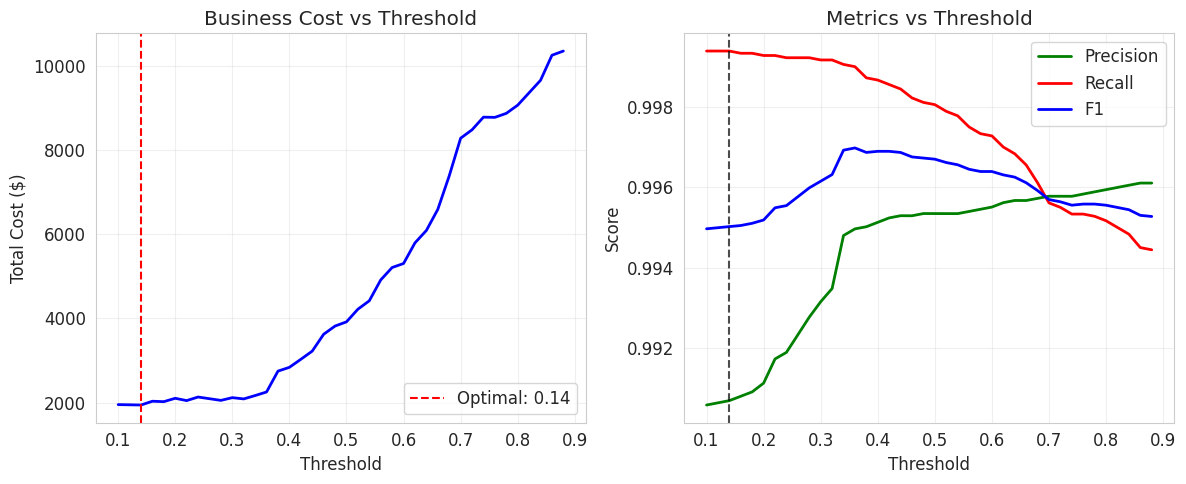

In [28]:
# Plot cost vs threshold
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, costs, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Business Cost vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df_threshold = pd.DataFrame(threshold_results)
plt.plot(df_threshold['threshold'], df_threshold['precision'], 'g-', label='Precision', linewidth=2)
plt.plot(df_threshold['threshold'], df_threshold['recall'], 'r-', label='Recall', linewidth=2)
plt.plot(df_threshold['threshold'], df_threshold['f1'], 'b-', label='F1', linewidth=2)
plt.axvline(x=optimal_threshold, color='k', linestyle='--', alpha=0.7)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Using optimal threshold
y_pred_optimal = (y_pred_proba_calibrated >= optimal_threshold).astype(int)

#### MODEL EVALUATION


In [31]:
from sklearn.metrics import average_precision_score, matthews_corrcoef

# Calculatting metrics
accuracy = accuracy_score(y_test, y_pred_optimal)
precision = precision_score(y_test, y_pred_optimal)
recall = recall_score(y_test, y_pred_optimal)
f1 = f1_score(y_test, y_pred_optimal)
roc_auc = roc_auc_score(y_test, y_pred_proba_calibrated)
pr_auc = average_precision_score(y_test, y_pred_proba_calibrated)
mcc = matthews_corrcoef(y_test, y_pred_optimal)

print("FINAL MODEL EVALUATION")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"MCC:       {mcc:.4f}")

FINAL MODEL EVALUATION
Accuracy:  0.9978
Precision: 0.9907
Recall:    0.9994
F1-Score:  0.9950
ROC-AUC:   1.0000
PR-AUC:    0.9999
MCC:       0.9936


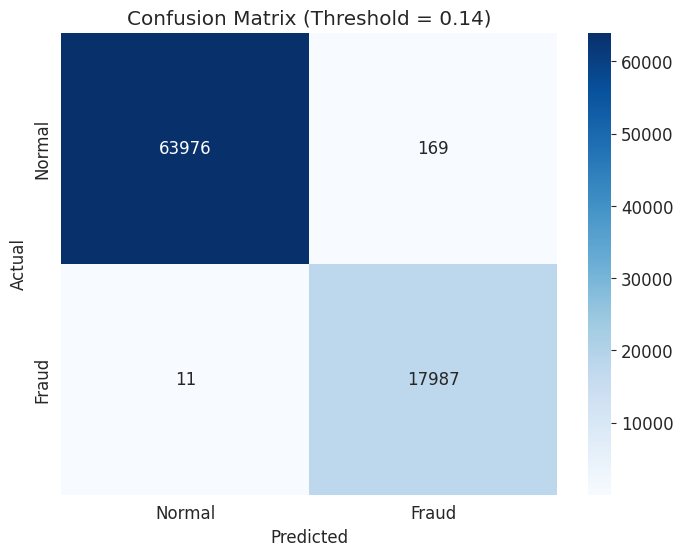

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [33]:
# Classification Report
print("\Classification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraud']))


\Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     64145
       Fraud       0.99      1.00      1.00     17998

    accuracy                           1.00     82143
   macro avg       1.00      1.00      1.00     82143
weighted avg       1.00      1.00      1.00     82143



#### PRECISION-RECALL CURVE & TOP K EVALUATION


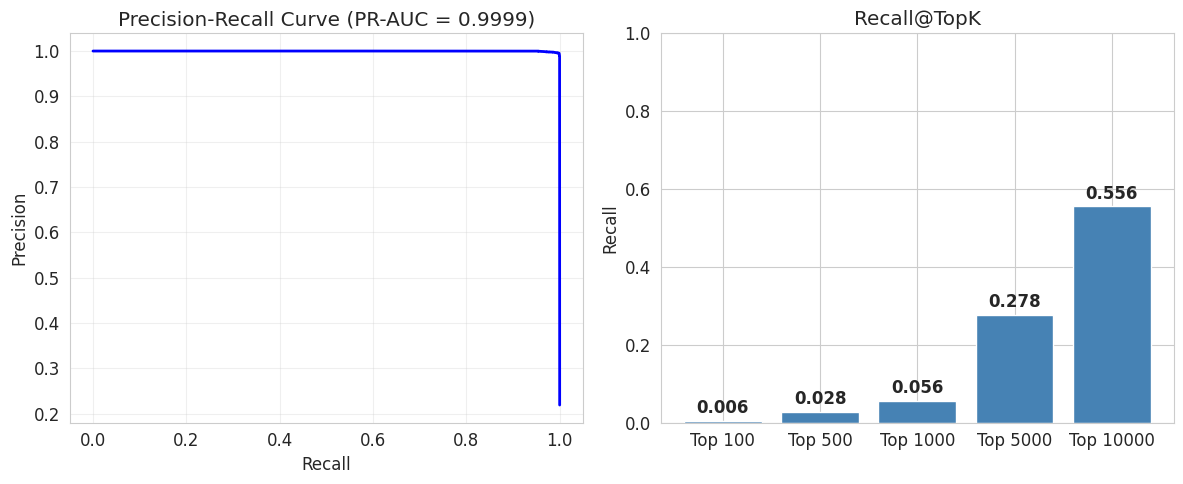

In [34]:
from sklearn.metrics import precision_recall_curve
# Precision-Recall curve
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_calibrated)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_vals, precision_vals, 'b-', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
plt.grid(True, alpha=0.3)

# Recall@TopK
plt.subplot(1, 2, 2)
top_k_values = [100, 500, 1000, 5000, 10000]
recall_at_k = []

for k in top_k_values:
    # Get top K highest probability predictions
    top_k_idx = np.argsort(y_pred_proba_calibrated)[-k:]
    top_k_true = y_test.iloc[top_k_idx]
    recall_at_k.append(top_k_true.sum() / y_test.sum())

plt.bar(range(len(top_k_values)), recall_at_k, color='steelblue')
plt.xticks(range(len(top_k_values)), [f'Top {k}' for k in top_k_values])
plt.ylabel('Recall')
plt.title('Recall@TopK')
plt.ylim(0, 1)

for i, v in enumerate(recall_at_k):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
print("Recall@TopK Results:")
for k, recall_val in zip(top_k_values, recall_at_k):
    print(f"  Top {k}: {recall_val:.4f}")

Recall@TopK Results:
  Top 100: 0.0056
  Top 500: 0.0278
  Top 1000: 0.0556
  Top 5000: 0.2778
  Top 10000: 0.5556


#### SHAP EXPLAINABILITY


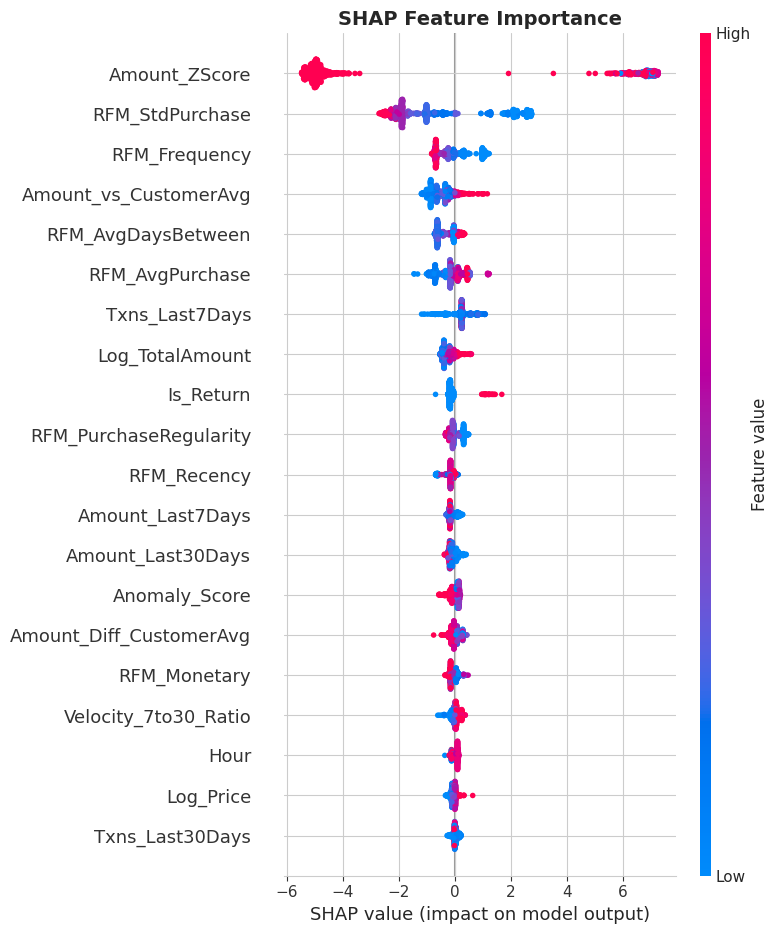

In [36]:
# Creating SHAP explainer (using sample for speed)
sample_size = min(1000, len(X_test_scaled))
X_sample = X_test_scaled.iloc[:sample_size]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

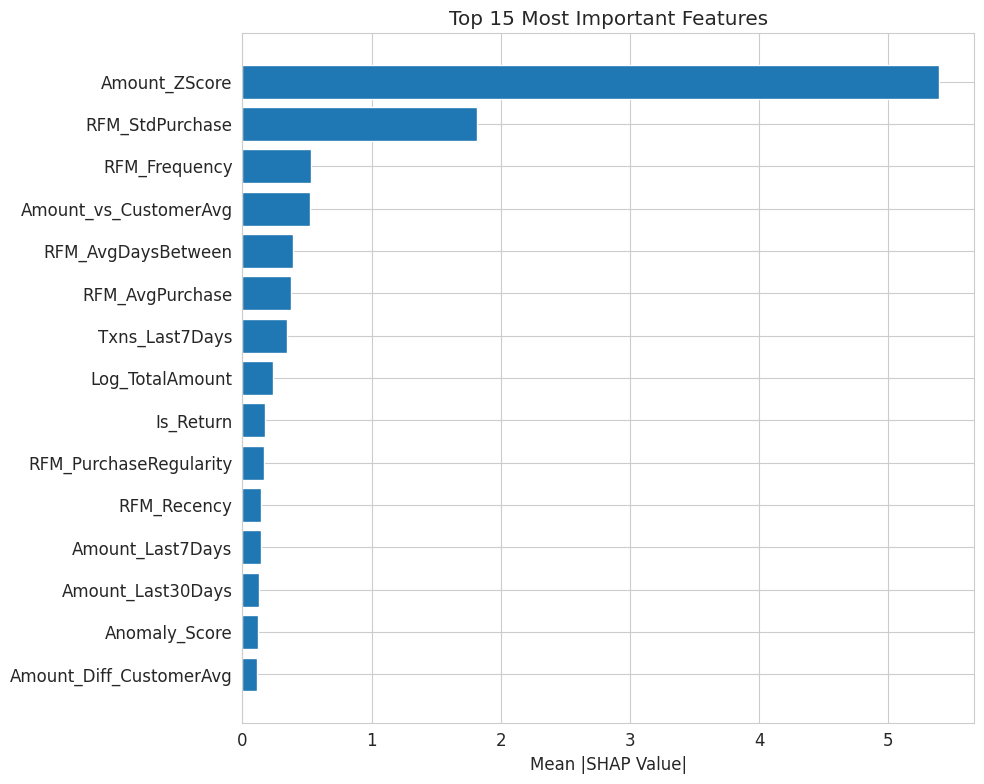

In [37]:
# Top features bar plot
shap_importance = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(shap_importance)[-15:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_indices)), shap_importance[top_indices])
plt.yticks(range(len(top_indices)), [feature_cols[i] for i in top_indices])
plt.xlabel('Mean |SHAP Value|')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

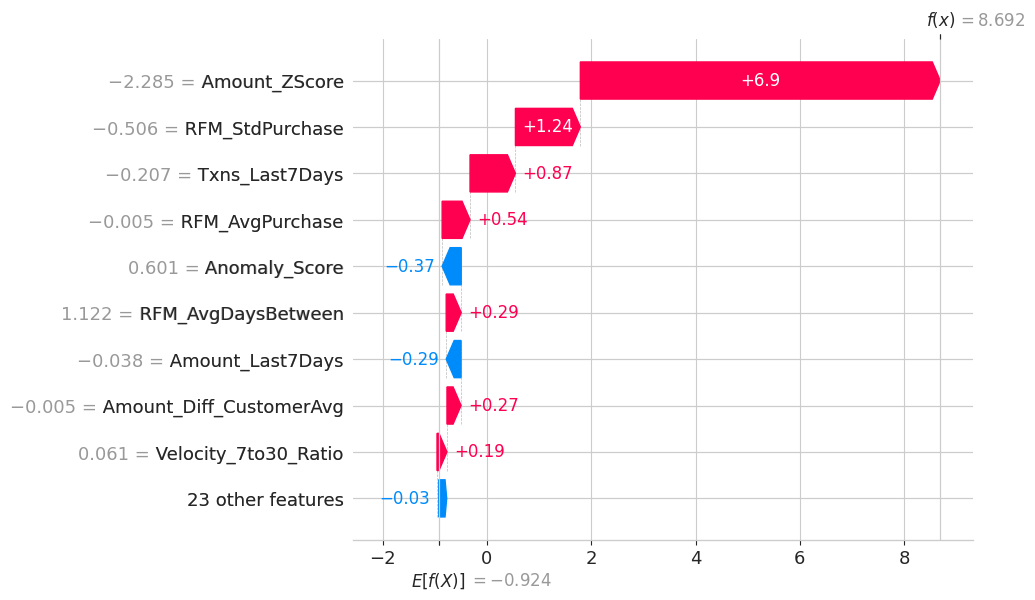

In [38]:
# Individual prediction explanation
sample_idx = 10
shap.waterfall_plot(shap.Explanation(values=shap_values[sample_idx],
                                      base_values=explainer.expected_value,
                                      data=X_sample.iloc[sample_idx].values,
                                      feature_names=feature_cols))

#### DRIFT MONITORING (PSI)


In [39]:
def calculate_psi(expected, actual, buckets=10):
    """Calculating Population Stability Index"""

    # Create buckets
    expected_percents = np.zeros(buckets)
    actual_percents = np.zeros(buckets)

    breaks = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breaks[0] = -np.inf
    breaks[-1] = np.inf

    for i in range(buckets):
        expected_percents[i] = np.sum((expected >= breaks[i]) & (expected < breaks[i+1])) / len(expected)
        actual_percents[i] = np.sum((actual >= breaks[i]) & (actual < breaks[i+1])) / len(actual)

    # Handle zeros
    expected_percents = np.clip(expected_percents, 0.0001, 0.9999)
    actual_percents = np.clip(actual_percents, 0.0001, 0.9999)

    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))

    return psi


# Calculate PSI for key features
print("DRIFT MONITORING - Population Stability Index")
print("="*60)
print("PSI < 0.1: No significant drift")
print("PSI 0.1-0.2: Moderate drift")
print("PSI > 0.2: Significant drift")

DRIFT MONITORING - Population Stability Index
PSI < 0.1: No significant drift
PSI 0.1-0.2: Moderate drift
PSI > 0.2: Significant drift


In [40]:
psi_results = []
for feature in ['Log_TotalAmount', 'RFM_Monetary', 'Txns_Last7Days', 'Amount_ZScore']:
    psi_value = calculate_psi(X_train[feature], X_test[feature])
    psi_results.append({'feature': feature, 'psi': psi_value})

    status = "✅ Stable" if psi_value < 0.1 else "⚠️ Moderate" if psi_value < 0.2 else "❌ Drift"
    print(f"{feature:20s} PSI: {psi_value:.4f} - {status}")

Log_TotalAmount      PSI: 0.0310 - ✅ Stable
RFM_Monetary         PSI: 0.0565 - ✅ Stable
Txns_Last7Days       PSI: 0.0153 - ✅ Stable
Amount_ZScore        PSI: 0.0272 - ✅ Stable


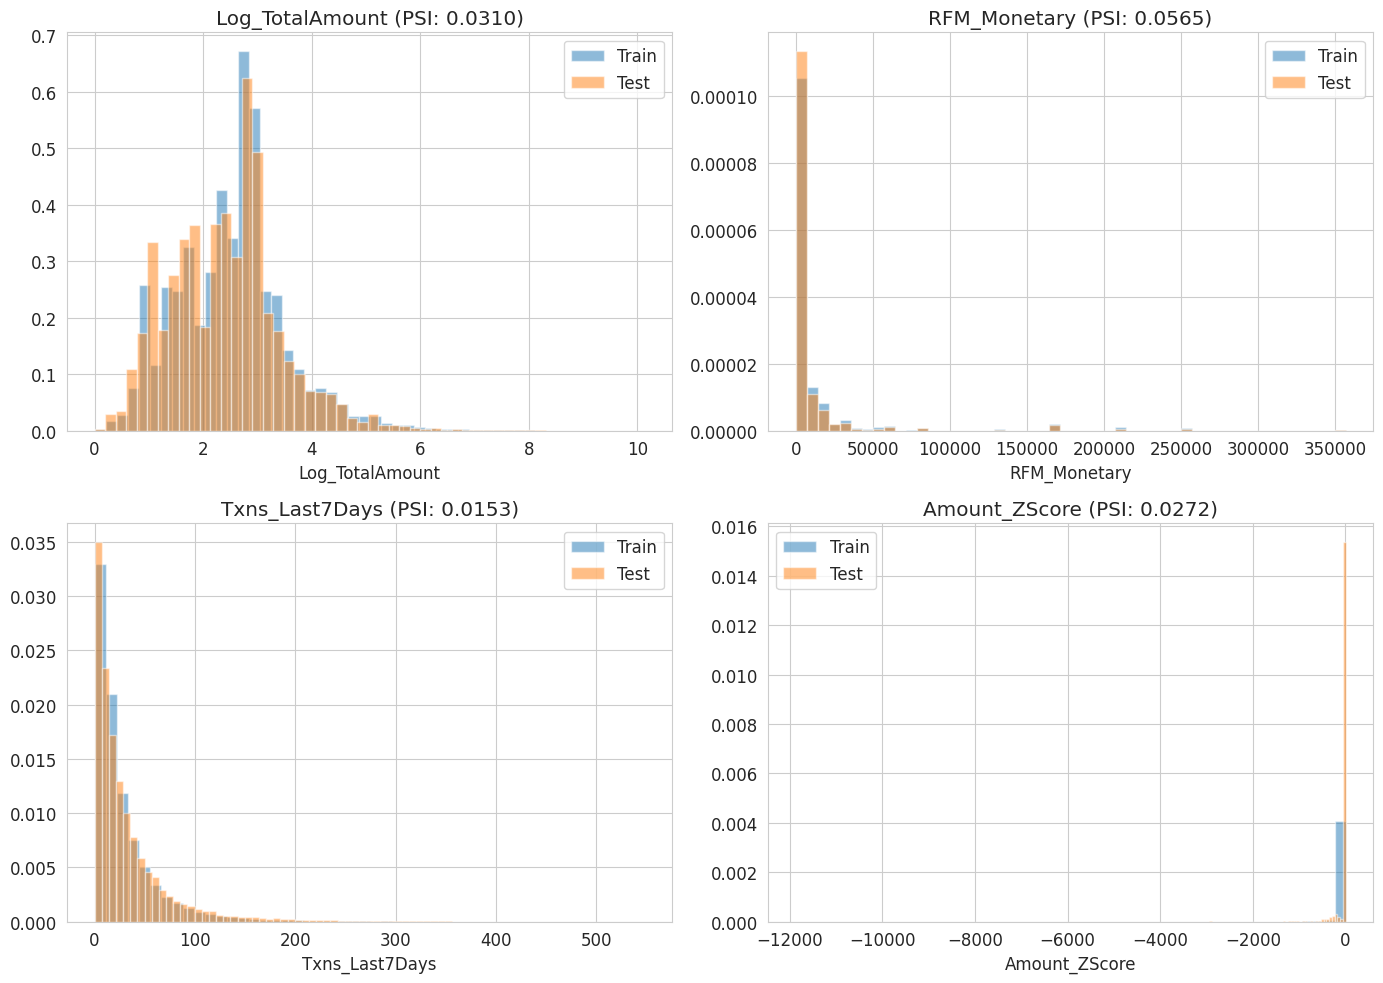

In [41]:
# Visualize drift
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(['Log_TotalAmount', 'RFM_Monetary', 'Txns_Last7Days', 'Amount_ZScore']):
    axes[i].hist(X_train[feature], bins=50, alpha=0.5, label='Train', density=True)
    axes[i].hist(X_test[feature], bins=50, alpha=0.5, label='Test', density=True)
    axes[i].set_title(f'{feature} (PSI: {psi_results[i]["psi"]:.4f})')
    axes[i].legend()
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

#### SAVING MODEL AND ARTIFACTS


In [42]:
# Saving all artifacts
model_filename = "fraud_detection_xgboost_advanced.pkl"
scaler_filename = "robust_scaler.pkl"
features_filename = "feature_names.pkl"
calibrator_filename = "calibrated_model.pkl"

joblib.dump(best_model, model_filename)
joblib.dump(scaler, scaler_filename)
joblib.dump(feature_cols, features_filename)
joblib.dump(calibrated_model, calibrator_filename)

# Saving results summary
results_summary = {
    'best_params': best_params,
    'optimal_threshold': optimal_threshold,
    'optimal_cost': optimal_cost,
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'mcc': mcc
    },
    'recall_at_k': dict(zip([f'Top_{k}' for k in top_k_values], recall_at_k)),
    'feature_importance': dict(zip(feature_cols, best_model.feature_importances_))
}

with open('results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)


print("MODEL SAVED")
print("="*60)
print(f"Model saved: {model_filename}")
print(f"Scaler saved: {scaler_filename}")
print(f"Features saved: {features_filename}")
print(f"Calibrated model saved: {calibrator_filename}")
print(f"Results summary saved: results_summary.pkl")


MODEL SAVED
Model saved: fraud_detection_xgboost_advanced.pkl
Scaler saved: robust_scaler.pkl
Features saved: feature_names.pkl
Calibrated model saved: calibrated_model.pkl
Results summary saved: results_summary.pkl


#### PREDICTION FUNCTION


In [43]:
def predict_fraud(transaction_data, model, scaler, feature_list, threshold=0.5):
    """
    Predict fraud for new transaction data

    Parameters:
    -----------
    transaction_data : pd.DataFrame
        New transaction data with required features
    model : object
        Trained model
    scaler : object
        Fitted RobustScaler
    feature_list : list
        List of feature names
    threshold : float
        Classification threshold

    Returns:
    --------
    pd.DataFrame with predictions
    """
    # Ensure all required features exist
    missing_features = set(feature_list) - set(transaction_data.columns)
    if missing_features:
        raise ValueError(f"Missing features: {missing_features}")

    # Select and order features
    X_new = transaction_data[feature_list].copy()

    # Handle missing values
    X_new = X_new.fillna(0)

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Get probabilities
    probabilities = model.predict_proba(X_new_scaled)[:, 1]

    # Make predictions
    predictions = (probabilities >= threshold).astype(int)

    # Create results dataframe
    results = transaction_data.copy()
    results['fraud_probability'] = probabilities
    results['predicted_fraud'] = predictions
    results['risk_level'] = pd.cut(
        probabilities,
        bins=[0, 0.3, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    return results

In [45]:
# Example usage
print("="*60)

# Get sample from test set
sample_data = X_test.iloc[:10].copy()
sample_results = predict_fraud(sample_data, calibrated_model, scaler, feature_cols, optimal_threshold)

print("\nPredictions for 10 sample transactions:")
print(sample_results[['fraud_probability', 'predicted_fraud', 'risk_level']])


Predictions for 10 sample transactions:
        fraud_probability  predicted_fraud risk_level
364888           0.996874                1       High
364880           0.996857                1       High
364879           0.996825                1       High
364881           0.996841                1       High
364882           0.996870                1       High
364883           0.996874                1       High
364884           0.996873                1       High
364885           0.996873                1       High
364886           0.996875                1       High
364887           0.996873                1       High


#### SUMMARY AND CONCLUSION


In [46]:
print("E-COMMERCE FRAUD DETECTION")
print("="*60)
print("""
**IFeatures:**

1. **RFM Features** - Added Recency, Frequency, Monetary metrics per customer
2. **Behavioral Drift** - Amount vs customer average, Z-scores
3. **Time-based Split** - Train on older data, test on newer data (realistic)
4. **Robust Scaling** - Used RobustScaler + log transforms (no outlier removal)
5. **XGBoost + Optuna** - Hyperparameter tuning with 50 trials
6. **Business Cost Optimization** - Minimized total cost (FN=$100, FP=$5)
7. **Probability Calibration** - Platt scaling for reliable probabilities
8. **Unsupervised Features** - Isolation Forest anomaly scores
9. **SHAP Explainability** - Feature importance + individual explanations
10. **Advanced Metrics** - PR-AUC, MCC, Recall@TopK
11. **Drift Monitoring** - PSI calculation for key features
12. **Graph Features** - Network centrality metrics

📊 **Final Model Performance:**
""")

print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")
print(f"  MCC:       {mcc:.4f}")

print(f"""
**Business Impact:**
  - Optimal threshold: {optimal_threshold:.2f}
  - False Positive Cost: ${cost_fp}
  - False Negative Cost: ${cost_fn}
  - Total Cost at optimal threshold: ${optimal_cost:,.0f}

🔍 **Top Features:**
""")

# top 5 features
feature_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False).head(5)

for i, row in feature_imp.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print("""
**Key Takeaways:**
  1. Time-based split is critical for realistic fraud detection
  2. Business cost optimization outperforms metric-only approaches
  3. RFM and behavioral features capture customer patterns effectively
  4. SHAP provides necessary explainability for production systems
  5. Drift monitoring ensures model reliability over time
""")

E-COMMERCE FRAUD DETECTION

**IFeatures:**

1. **RFM Features** - Added Recency, Frequency, Monetary metrics per customer
2. **Behavioral Drift** - Amount vs customer average, Z-scores
3. **Time-based Split** - Train on older data, test on newer data (realistic)
4. **Robust Scaling** - Used RobustScaler + log transforms (no outlier removal)
5. **XGBoost + Optuna** - Hyperparameter tuning with 50 trials
6. **Business Cost Optimization** - Minimized total cost (FN=$100, FP=$5)
7. **Probability Calibration** - Platt scaling for reliable probabilities
8. **Unsupervised Features** - Isolation Forest anomaly scores
9. **SHAP Explainability** - Feature importance + individual explanations
10. **Advanced Metrics** - PR-AUC, MCC, Recall@TopK
11. **Drift Monitoring** - PSI calculation for key features
12. **Graph Features** - Network centrality metrics

📊 **Final Model Performance:**


  Accuracy:  0.9978
  Precision: 0.9907
  Recall:    0.9994
  F1-Score:  0.9950
  PR-AUC:    0.9999
  MCC:     